# Apache Arrow Variable Sharing

This notebook demonstrates the tabular-data part of the DataX unified namespace feature.

The focus is Arrow-compatible tabular transfer: pandas DataFrames and R data.frames moving between languages while preserving rows, columns, dtypes, and missing values. PyArrow validates the source schema inside Python; raw `pyarrow.Table` objects are not synchronized by the browser kernel. The non-tabular namespace basics are covered in `02_multilanguage_data_analysis.ipynb`.

## 1. Build a Typed Table in Python

Start with a pandas DataFrame and create a PyArrow Table from the same data. The schema gives us a concrete baseline for what should survive the language boundary.

In [1]:
import pandas as pd
import pyarrow as pa

raw_titanic = pd.read_csv("data/titanic.csv")

passengers = raw_titanic[["Pclass", "Sex", "Age", "Fare", "Survived", "Embarked"]].rename(
    columns={
        "Pclass": "pclass",
        "Sex": "sex",
        "Age": "age",
        "Fare": "fare",
        "Survived": "survived",
        "Embarked": "embarked",
    }
)

passengers = passengers.astype({
    "pclass": "int64",
    "age": "float64",
    "fare": "float64",
    "survived": "int64",
})

# Keep text columns as plain object arrays with None for missing values.
# (Converting pandas "string" columns that contain pd.NA fails in this
# pyarrow build with: ArrowTypeError: Expected bytes, got a 'NAType' object.)
for text_column in ("sex", "embarked"):
    passengers[text_column] = passengers[text_column].astype("object").where(
        passengers[text_column].notna(), None
    )

passenger_table = pa.Table.from_pandas(passengers, preserve_index=False)
schema_text = str(passenger_table.schema)
del passenger_table

row_count = passengers.shape[0]
column_count = passengers.shape[1]

print(f"Rows: {row_count}")
print(f"Columns: {column_count}")
print("\nArrow schema:")
print(schema_text)

Rows: 891
Columns: 6

Arrow schema:
pclass: int64
sex: string
age: double
fare: double
survived: int64
embarked: string
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 753


In [2]:
print("Pandas dtypes:")
print(passengers.dtypes)

print("\nMissing values:")
print(passengers.isna().sum())

Pandas dtypes:
pclass        int64
sex          object
age         float64
fare        float64
survived      int64
embarked     object
dtype: object

Missing values:
pclass        0
sex           0
age         177
fare          0
survived      0
embarked      2
dtype: int64


In [3]:
passengers.head(8)

,pclass,sex,age,fare,survived,embarked
0,3,male,22.0,7.2500,0,S
1,1,female,38.0,71.2833,1,C
2,3,female,26.0,7.9250,1,S
3,1,female,35.0,53.1000,1,S
4,3,male,35.0,8.0500,0,S
5,3,male,NaN,8.4583,0,Q
6,1,male,54.0,51.8625,0,S
7,3,male,2.0,21.0750,0,S


## 2. Receive the Python Table in R

The Python DataFrame crosses the boundary as a tabular value. In R, it should behave like a normal data.frame with the same columns and missing-value pattern.

In [4]:
%%R
cat("R class:", paste(class(passengers), collapse = ", "), "\n")
cat("Dimensions:", nrow(passengers), "x", ncol(passengers), "\n\n")

cat("Column classes:\n")
print(sapply(passengers, class))

cat("\nMissing values:\n")
print(colSums(is.na(passengers)))

R class: data.frame 
Dimensions: 891 x 6 

Column classes:
     pclass         sex         age        fare    survived    embarked 
  "integer" "character"   "numeric"   "numeric"   "integer" "character" 

Missing values:
  pclass      sex      age     fare survived embarked 
       0        0      177        0        0        0 

In [5]:
%%R
class_summary <- aggregate(survived ~ pclass, data = passengers, FUN = mean)
names(class_summary)[names(class_summary) == "survived"] <- "survival_rate"

fare_summary <- aggregate(fare ~ pclass, data = passengers, FUN = function(values) round(mean(values, na.rm = TRUE), 2))
names(fare_summary)[names(fare_summary) == "fare"] <- "mean_fare"

class_counts <- as.data.frame(table(passengers$pclass))
names(class_counts) <- c("pclass", "passenger_count")
class_counts$pclass <- as.integer(as.character(class_counts$pclass))
class_counts$passenger_count <- as.integer(class_counts$passenger_count)

class_summary <- merge(class_summary, fare_summary, by = "pclass")
class_summary <- merge(class_summary, class_counts, by = "pclass")
class_summary$survival_rate <- round(class_summary$survival_rate, 4)
class_summary <- class_summary[order(class_summary$pclass), ]

row_count_r <- nrow(passengers)
column_count_r <- ncol(passengers)
missing_age_r <- sum(is.na(passengers$age))

print(class_summary)

  pclass survival_rate mean_fare passenger_count
1      1        0.6296     84.15             216
2      2        0.4728     20.66             184
3      3        0.2424     13.68             491

## 3. Bring an R data.frame Back to Python

R created `class_summary` as a data.frame. Python receives it as a tabular object that can be inspected and plotted like any other pandas DataFrame.

In [6]:
print(type(class_summary))
print(class_summary.dtypes)

assert int(row_count_r) == row_count
assert int(column_count_r) == column_count

class_summary

<class 'pandas.core.frame.DataFrame'>
mean_fare          float64
passenger_count      int64
pclass               int64
survival_rate      float64
dtype: object


,mean_fare,passenger_count,pclass,survival_rate
0,84.15,216,1,0.6296
1,20.66,184,2,0.4728
2,13.68,491,3,0.2424


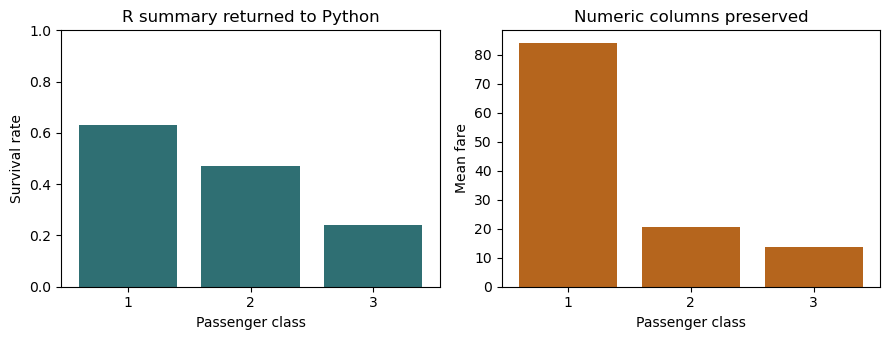

In [7]:
import matplotlib.pyplot as plt

summary_for_plot = class_summary.sort_values("pclass")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

axes[0].bar(summary_for_plot["pclass"].astype(str), summary_for_plot["survival_rate"], color="#2f6f73")
axes[0].set_ylim(0, 1)
axes[0].set_xlabel("Passenger class")
axes[0].set_ylabel("Survival rate")
axes[0].set_title("R summary returned to Python")

axes[1].bar(summary_for_plot["pclass"].astype(str), summary_for_plot["mean_fare"], color="#b5651d")
axes[1].set_xlabel("Passenger class")
axes[1].set_ylabel("Mean fare")
axes[1].set_title("Numeric columns preserved")

fig.tight_layout()
plt.show()

## 4. Prepare a Compact Arrow-Compatible DataFrame

Build the compact pandas DataFrame that will cross the language boundary and normalize each column to an Arrow-compatible numeric dtype.

The notebook already validated pandas-to-Arrow conversion before the language round trip. Avoiding a second PyArrow call here works around a dynamic-side-module signature mismatch in the browser WASM build.

In [8]:
# Clean up raw Arrow objects left by an earlier version of this notebook.
globals().pop("passenger_table", None)
globals().pop("_compact_arrow_local", None)
globals().pop("compact_arrow", None)

compact_df = summary_for_plot[[
    "pclass",
    "survival_rate",
    "mean_fare",
    "passenger_count",
]].astype({
    "pclass": "int64",
    "survival_rate": "float64",
    "mean_fare": "float64",
    "passenger_count": "int64",
}).reset_index(drop=True)

compact_schema_text = "\n".join([
    "pclass: int64",
    "survival_rate: double",
    "mean_fare: double",
    "passenger_count: int64",
])
compact_row_count, compact_column_count = compact_df.shape

print(compact_schema_text)
compact_df

pclass: int64
survival_rate: double
mean_fare: double
passenger_count: int64


,pclass,survival_rate,mean_fare,passenger_count
0,1,0.6296,84.15,216
1,2,0.4728,20.66,184
2,3,0.2424,13.68,491


## 5. Receive the Compact DataFrame in R

R receives `compact_df` as a native `data.frame` with the expected number of rows and columns.

In [9]:
%%R
cat("compact_df class:", paste(class(compact_df), collapse = ", "), "\n")
cat("compact_df dimensions:", nrow(compact_df), "x", ncol(compact_df), "\n")
print(compact_df)

compact_rows_r <- nrow(compact_df)
compact_cols_r <- ncol(compact_df)

compact_df class: data.frame 
compact_df dimensions: 3 x 4 
  pclass survival_rate mean_fare passenger_count
1      1        0.6296     84.15             216
2      2        0.4728     20.66             184
3      3        0.2424     13.68             491

## 6. Summarize the Transfer in JavaScript

JavaScript can consume the shared scalar metadata produced by Python and R to build a compact transfer report.

In [10]:
%%js
const arrow_transfer_report = {
  sourceRows: row_count,
  sourceColumns: column_count,
  rRows: row_count_r,
  rColumns: column_count_r,
  compactRows: compact_row_count,
  compactRowsSeenByR: compact_rows_r,
  compactColumnsSeenByR: compact_cols_r,
  schemaPreview: compact_schema_text.split("\n").slice(0, 4)
};

const arrow_transfer_report_text = [
  `Python DataFrame rows: ${arrow_transfer_report.sourceRows}`,
  `R received table: ${arrow_transfer_report.rRows} x ${arrow_transfer_report.rColumns}`,
  `Arrow-compatible compact DataFrame rows: ${arrow_transfer_report.compactRows}`,
  `R received compact DataFrame: ${arrow_transfer_report.compactRowsSeenByR} x ${arrow_transfer_report.compactColumnsSeenByR}`,
  "Compact schema:",
  ...arrow_transfer_report.schemaPreview.map(line => `  ${line}`)
].join("\n");

console.log(arrow_transfer_report_text);

Python DataFrame rows: 891
R received table: 891 x 6
Arrow-compatible compact DataFrame rows: 3
R received compact DataFrame: 3 x 4
Compact schema:
  pclass: int64
  survival_rate: double
  mean_fare: double
  passenger_count: int64


## 7. Final Verification in Python

The final cell checks that the row and column counts survived the table transfers and prints the cross-language report from JavaScript.

In [11]:
assert row_count == int(row_count_r)
assert column_count == int(column_count_r)
assert compact_row_count == int(compact_rows_r)
assert compact_column_count == int(compact_cols_r)

print(arrow_transfer_report_text)
print("\nOriginal Arrow schema:")
print(schema_text)

Python DataFrame rows: 891
R received table: 891 x 6
Arrow-compatible compact DataFrame rows: 3
R received compact DataFrame: 3 x 4
Compact schema:
  pclass: int64
  survival_rate: double
  mean_fare: double
  passenger_count: int64

Original Arrow schema:
pclass: int64
sex: string
age: double
fare: double
survived: int64
embarked: string
-- schema metadata --
pandas: '{"index_columns": [], "column_indexes": [], "columns": [{"name":' + 753


## Summary

| Transfer | Source language | Target language | What this notebook checks |
|----------|-----------------|-----------------|---------------------------|
| pandas DataFrame | Python | R | Column names, row count, column count, missing values |
| R data.frame | R | Python | Returned table shape, numeric columns, pandas plotting |
| Arrow-compatible DataFrame | Python | R | Normalized numeric dtypes transferred without synchronizing a raw Arrow object |
| Transfer metadata | Python/R | JavaScript | Shared scalar metadata for reporting |

The notebook keeps the analysis intentionally small so the Apache Arrow-related namespace behavior stays visible.